# Access the analysis ready satellite soil moisture data

This notebook provides an example of how to open the satellite-soil-moisture Zarr store using xarray.
You will need to insert your CDS API key where indicated in the following code cell (available on [your profile page](https://cds.climate.copernicus.eu/profile)).
For more information on using the Data Store Analysis Ready Datasets, please see the [user documentation pages](https://cds.climate.copernicus.eu/datasets/how-to-use-the-dss-arco-dataset).

In [1]:
import os
cdsapi_key = "<INSERT-CDS-API-KEY-HERE>"

# The following attempts to find the CDSAPI key in your environment.
if cdsapi_key == "<INSERT-CDS-API-KEY-HERE>":
    cdsapi_key = None
if cdsapi_key is None:
    cdsapi_key = os.getenv("CDSAPI_KEY")
if cdsapi_key is None and os.path.exists(os.path.expanduser("~/.cdsapirc")):
    with open(os.path.expanduser("~/.cdsapirc"), "r") as f:
        for line in f:
            if line.startswith("key:"):
                cdsapi_key = line.split(":")[1].strip()
                break
if cdsapi_key is None:
    raise ValueError("CDSAPI key not found. Please set the CDSAPI_KEY environment variable or create a ~/.cdsapirc file.")


## Plug and play access

The code below provides a simple plug and play example of how to use the Zarr Store for light-weight access.

This dataset contains **26 sub-items** covering different temporal resolutions (daily, ten-daily, monthly) and different retrieval approaches (active microwave, passive microwave, combined). The URLs below show a selection of key sub-items; the full list of sub-item identifiers follows the pattern `{tcdr|icdr}-ssm-{active|passive|combined}-{daily|ten-daily|monthly}`. The example below uses the ICDR combined daily data.

In [2]:
import xarray as xr

# Geo-chunked ICDR combined soil moisture (daily)
geochunked_icdr_ssm_combined_daily_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-053/arco/satellite_soil_moisture/icdr-ssm-combined-daily/geoChunked.zarr"

# Time-chunked ICDR combined soil moisture (daily)
timechunked_icdr_ssm_combined_daily_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-053/arco/satellite_soil_moisture/icdr-ssm-combined-daily/timeChunked.zarr"

# Geo-chunked ICDR active microwave soil moisture (daily)
geochunked_icdr_ssm_active_daily_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-053/arco/satellite_soil_moisture/icdr-ssm-active-daily/geoChunked.zarr"

# Time-chunked ICDR active microwave soil moisture (daily)
timechunked_icdr_ssm_active_daily_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-053/arco/satellite_soil_moisture/icdr-ssm-active-daily/timeChunked.zarr"

# Geo-chunked ICDR passive microwave soil moisture (daily)
geochunked_icdr_ssm_passive_daily_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-053/arco/satellite_soil_moisture/icdr-ssm-passive-daily/geoChunked.zarr"

# Time-chunked ICDR passive microwave soil moisture (daily)
timechunked_icdr_ssm_passive_daily_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-053/arco/satellite_soil_moisture/icdr-ssm-passive-daily/timeChunked.zarr"

# Geo-chunked ICDR active microwave soil moisture (monthly)
geochunked_icdr_ssm_active_monthly_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-053/arco/satellite_soil_moisture/icdr-ssm-active-monthly/geoChunked.zarr"

# Time-chunked ICDR active microwave soil moisture (monthly)
timechunked_icdr_ssm_active_monthly_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-053/arco/satellite_soil_moisture/icdr-ssm-active-monthly/timeChunked.zarr"

# Geo-chunked ICDR active microwave soil moisture (ten-daily)
geochunked_icdr_ssm_active_ten_daily_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-053/arco/satellite_soil_moisture/icdr-ssm-active-ten-daily/geoChunked.zarr"

# Time-chunked ICDR active microwave soil moisture (ten-daily)
timechunked_icdr_ssm_active_ten_daily_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-053/arco/satellite_soil_moisture/icdr-ssm-active-ten-daily/timeChunked.zarr"


# Open the zarr store with xarray, users must insert their API key where indicated.
ds = xr.open_zarr(
    timechunked_icdr_ssm_combined_daily_url,
    consolidated=True,
     storage_options = {
        "headers": {"Authorization": f"Bearer {cdsapi_key}"}
    }
)
 
# Inspect the variables
ds

<xarray.Dataset> Size: 13GB
Dimensions:         (time: 444, latitude: 720, longitude: 1440)
Coordinates:
  * time            (time) datetime64[ns] 4kB 2025-01-01 ... 2026-03-20
  * latitude        (latitude) float32 3kB -89.88 -89.62 -89.38 ... 89.62 89.88
  * longitude       (longitude) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables:
    dnflag          (time, latitude, longitude) int8 460MB dask.array<chunksize=(1, 720, 1024), meta=np.ndarray>
    flag            (time, latitude, longitude) float32 2GB dask.array<chunksize=(1, 720, 1024), meta=np.ndarray>
    freqbandID      (time, latitude, longitude) int16 921MB dask.array<chunksize=(1, 720, 1024), meta=np.ndarray>
    mode            (time, latitude, longitude) int8 460MB dask.array<chunksize=(1, 720, 1024), meta=np.ndarray>
    sensor          (time, latitude, longitude) int32 2GB dask.array<chunksize=(1, 720, 1024), meta=np.ndarray>
    sm              (time, latitude, longitude) float32 2GB dask.array<chunksize=(1, 720, 1024), meta=np.ndarray>
    sm_uncertainty  (time, latitude, longitude) float32 2GB dask.array<chunksize=(1, 720, 1024), meta=np.ndarray>
    t0              (time, latitude, longitude) datetime64[ns] 4GB dask.array<chunksize=(1, 720, 1024), meta=np.ndarray>

Plot a map of surface soil moisture using earthkit-plots.

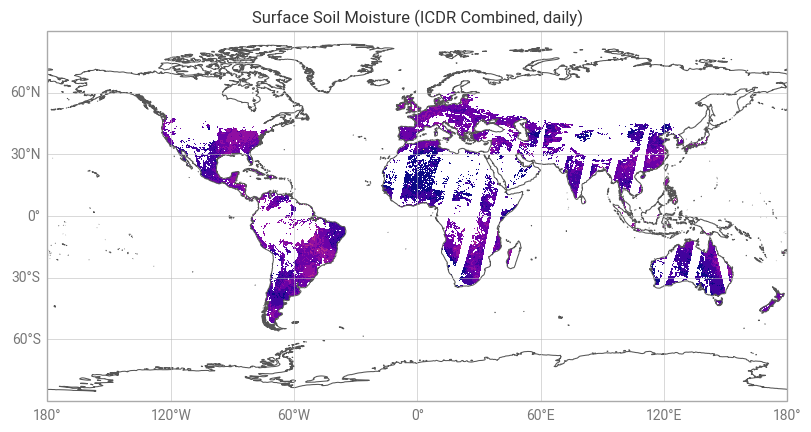

In [3]:
from earthkit import plots as ekp

# Select a single time step to plot
plot_data = ds["sm"].sel(time="2020-06-01", method="nearest")

chart = ekp.Map()

chart.grid_cells(plot_data)

chart.coastlines()
chart.gridlines()

chart.title("Surface Soil Moisture (ICDR Combined, daily)")

chart.show()

## Advanced usage

If your workflow requires access to larger amounts of data, it is recommended that you include a retry mechanism.
This is not provided in the current default zarr engine for xarray, instead we can define a custom "`store`" which is
used when connecting to the remote zarr data.

In [4]:
!pip install -q obstore
import xarray as xr
from obstore.store import HTTPStore
from zarr.storage import ObjectStore

# Geo-chunked ICDR combined soil moisture (daily)
geochunked_icdr_ssm_combined_daily_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-053/arco/satellite_soil_moisture/icdr-ssm-combined-daily/geoChunked.zarr"

# Time-chunked ICDR combined soil moisture (daily)
timechunked_icdr_ssm_combined_daily_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-053/arco/satellite_soil_moisture/icdr-ssm-combined-daily/timeChunked.zarr"

# Geo-chunked ICDR active microwave soil moisture (daily)
geochunked_icdr_ssm_active_daily_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-053/arco/satellite_soil_moisture/icdr-ssm-active-daily/geoChunked.zarr"

# Time-chunked ICDR active microwave soil moisture (daily)
timechunked_icdr_ssm_active_daily_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-053/arco/satellite_soil_moisture/icdr-ssm-active-daily/timeChunked.zarr"

# Geo-chunked ICDR passive microwave soil moisture (daily)
geochunked_icdr_ssm_passive_daily_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-053/arco/satellite_soil_moisture/icdr-ssm-passive-daily/geoChunked.zarr"

# Time-chunked ICDR passive microwave soil moisture (daily)
timechunked_icdr_ssm_passive_daily_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-053/arco/satellite_soil_moisture/icdr-ssm-passive-daily/timeChunked.zarr"

# Geo-chunked ICDR active microwave soil moisture (monthly)
geochunked_icdr_ssm_active_monthly_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-053/arco/satellite_soil_moisture/icdr-ssm-active-monthly/geoChunked.zarr"

# Time-chunked ICDR active microwave soil moisture (monthly)
timechunked_icdr_ssm_active_monthly_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-053/arco/satellite_soil_moisture/icdr-ssm-active-monthly/timeChunked.zarr"

# Geo-chunked ICDR active microwave soil moisture (ten-daily)
geochunked_icdr_ssm_active_ten_daily_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-053/arco/satellite_soil_moisture/icdr-ssm-active-ten-daily/geoChunked.zarr"

# Time-chunked ICDR active microwave soil moisture (ten-daily)
timechunked_icdr_ssm_active_ten_daily_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-053/arco/satellite_soil_moisture/icdr-ssm-active-ten-daily/timeChunked.zarr"


# Use obstore's HTTPStore to create a store with retry configuration,
# and then wrap it in a zarr ObjectStore to read with xarray.
# See https://github.com/developmentseed/obstore/blob/main/obstore/python/obstore/_store/_retry.pyi
# for more details on the retry configuration options.
http_store = HTTPStore(
    geochunked_icdr_ssm_combined_daily_url,
    client_options={
        "default_headers": {"Authorization": f"Bearer {cdsapi_key}"},
    },
)
store = ObjectStore(http_store, read_only=True)
ds = xr.open_zarr(store)
ds

<xarray.Dataset> Size: 13GB
Dimensions:         (time: 444, latitude: 720, longitude: 1440)
Coordinates:
  * time            (time) datetime64[ns] 4kB 2025-01-01 ... 2026-03-20
  * latitude        (latitude) float32 3kB -89.88 -89.62 -89.38 ... 89.62 89.88
  * longitude       (longitude) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables:
    dnflag          (time, latitude, longitude) int8 460MB dask.array<chunksize=(444, 32, 64), meta=np.ndarray>
    flag            (time, latitude, longitude) float32 2GB dask.array<chunksize=(444, 32, 64), meta=np.ndarray>
    freqbandID      (time, latitude, longitude) int16 921MB dask.array<chunksize=(444, 32, 64), meta=np.ndarray>
    mode            (time, latitude, longitude) int8 460MB dask.array<chunksize=(444, 32, 64), meta=np.ndarray>
    sensor          (time, latitude, longitude) int32 2GB dask.array<chunksize=(444, 32, 64), meta=np.ndarray>
    sm              (time, latitude, longitude) float32 2GB dask.array<chunksize=(444, 32, 64), meta=np.ndarray>
    sm_uncertainty  (time, latitude, longitude) float32 2GB dask.array<chunksize=(444, 32, 64), meta=np.ndarray>
    t0              (time, latitude, longitude) datetime64[ns] 4GB dask.array<chunksize=(444, 32, 64), meta=np.ndarray>

The result is the same as the previous example, this just provides a more robust connection, preventing your
workflow crashing due to temporary network issues.